In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [ ]:
df = pd.read_csv("updated_dataset.csv")

df.head()

,comment,label
0,bharat aman ka qaatil hai,A
1,story whi poorani ruposh wali ha on record aga...,NaN
2,in haramzadon per hamaray paisey kharch nahi h...,A
3,astagfirullah allah allah kesy dramay bntay ja...,NaN
4,shehbaz sharif tum woh nahi ho jo bn ke dikha ...,A


In [ ]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

comment       1
label      3822
dtype: int64


In [ ]:
# Remove rows where comment is missing
df = df.dropna(subset=['comment'])

# Replace missing labels with NA
df['label'] = df['label'].fillna('NA')

print("After handling missing values:")
print(df.isnull().sum())

After handling missing values:
comment    0
label      0
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 264


In [ ]:
df = df.drop_duplicates()

print("Dataset size after removing duplicates:", df.shape)


print(df['label'].value_counts())

Dataset size after removing duplicates: (7526, 2)
label
A     3964
NA    3562
Name: count, dtype: int64


In [ ]:
def clean_text(text):

    text = str(text)

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove special characters
    text = re.sub(r"[^\w\s]", "", text)

    # lowercase
    text = text.lower()

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df['clean_comment'] = df['comment'].apply(clean_text)


df[['comment','clean_comment']].head()

,comment,clean_comment
0,bharat aman ka qaatil hai,bharat aman ka qaatil hai
1,story whi poorani ruposh wali ha on record aga...,story whi poorani ruposh wali ha on record aga...
2,in haramzadon per hamaray paisey kharch nahi h...,in haramzadon per hamaray paisey kharch nahi h...
3,astagfirullah allah allah kesy dramay bntay ja...,astagfirullah allah allah kesy dramay bntay ja...
4,shehbaz sharif tum woh nahi ho jo bn ke dikha ...,shehbaz sharif tum woh nahi ho jo bn ke dikha ...


In [ ]:
stopwords = [
"hai","ho","ka","ki","ke","ko","mein","ma","tha","thi","the",
"ye","wo","aur","ya","to","se","par","bhi","tum","main"
]

In [ ]:
def remove_stopwords(text):

    words = text.split()

    filtered = [word for word in words if word not in stopwords]

    return " ".join(filtered)
df['clean_comment'] = df['clean_comment'].apply(remove_stopwords)

In [ ]:
df['clean_comment'] = df['clean_comment'].str.strip()

In [ ]:
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=10000,
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df['clean_comment'])

y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5644, 10000)
Testing size: (1882, 10000)


In [ ]:
models = {

    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": LinearSVC()
}

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    results[name] = acc

    print("\nModel:", name)

    print("Accuracy:", acc)

    print("\nClassification Report:\n")

    print(classification_report(y_test, predictions))


Model: Naive Bayes
Accuracy: 0.9240170031880978

Classification Report:

              precision    recall  f1-score   support

           A       0.92      0.94      0.93       991
          NA       0.93      0.91      0.92       891

    accuracy                           0.92      1882
   macro avg       0.92      0.92      0.92      1882
weighted avg       0.92      0.92      0.92      1882


Model: Logistic Regression
Accuracy: 0.9319872476089267

Classification Report:

              precision    recall  f1-score   support

           A       0.94      0.94      0.94       991
          NA       0.93      0.93      0.93       891

    accuracy                           0.93      1882
   macro avg       0.93      0.93      0.93      1882
weighted avg       0.93      0.93      0.93      1882


Model: SVM
Accuracy: 0.9335812964930924

Classification Report:

              precision    recall  f1-score   support

           A       0.94      0.93      0.94       991
          NA   

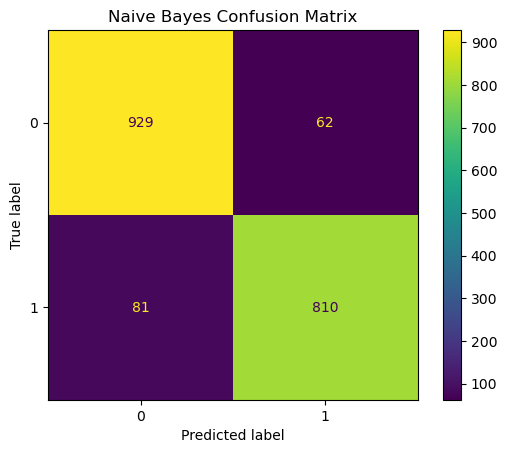

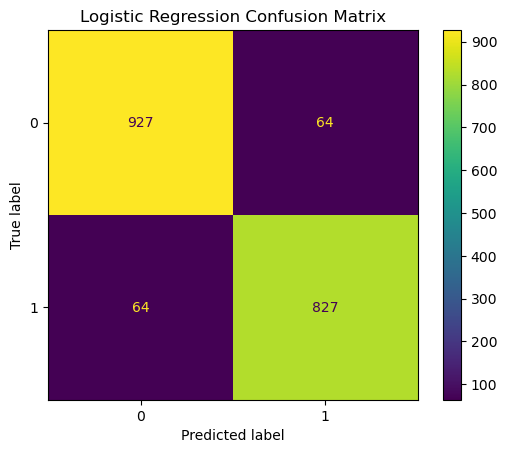

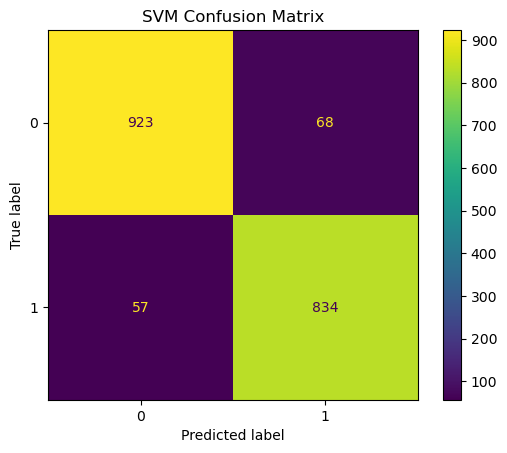

In [ ]:
for name, model in models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()

    plt.title(name + " Confusion Matrix")

    plt.show()

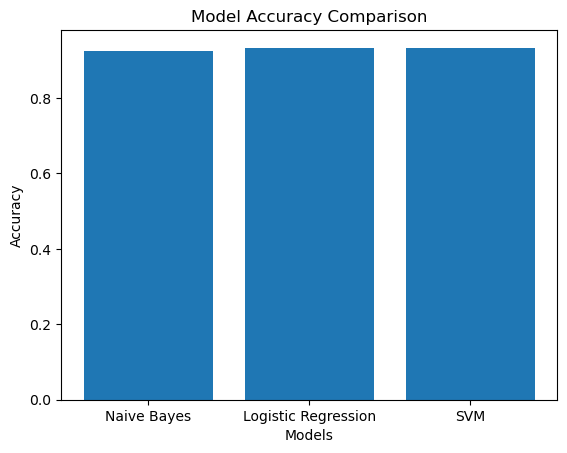

In [ ]:
names = list(results.keys())
values = list(results.values())

plt.figure()

plt.bar(names, values)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xlabel("Models")

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Model": results.keys(),
    "Accuracy": results.values()
})

comparison

,Model,Accuracy
0,Naive Bayes,0.924017
1,Logistic Regression,0.931987
2,SVM,0.933581


In [ ]:
def predict_comment(comment, model, vectorizer):

    # Cleaning function (same as training)
    import re
    
    def clean_text(text):
        text = str(text)
        text = re.sub(r"http\S+|www\S+", "", text)
        text = re.sub(r"\d+", "", text)
        text = re.sub(r"[^\w\s]", "", text)
        text = text.lower()
        text = re.sub(r"\s+", " ", text).strip()
        return text

    # Stopwords
    stopwords = [
        "hai","ho","ka","ki","ke","ko","mein","ma",
        "tha","thi","the","ye","wo","aur","ya","to",
        "se","par","bhi","tum","main"
    ]

    def remove_stopwords(text):
        words = text.split()
        filtered = [word for word in words if word not in stopwords]
        return " ".join(filtered)

    # Preprocess comment
    comment = clean_text(comment)
    comment = remove_stopwords(comment)

    # Vectorize
    comment_vector = vectorizer.transform([comment])

    # Predict
    prediction = model.predict(comment_vector)[0]

    return prediction

In [ ]:
model = models["SVM"]

In [ ]:
test_comments = [
    "tum pagal ho",
    "Dushman ho tum",
    "ye video bohat achi hai",
    "bakwas band karo",
    "acha kaam hai",
    "Teri maa ki",
    "tujhe ni smjh aa rhii",
    "Bhaiyya bakwaas mat kar",
    "andha hai kya",
    "kutta acha ha",
    "Chal hatt dimagh mat kharab kar",
    "kisi nachnay wali k bachay"
]

for comment in test_comments:

    label = predict_comment(comment, model, vectorizer)

    print(comment, "->", label)

tum pagal ho -> A
Dushman ho tum -> A
ye video bohat achi hai -> NA
bakwas band karo -> A
acha kaam hai -> NA
Teri maa ki -> A
tujhe ni smjh aa rhii -> NA
Bhaiyya bakwaas mat kar -> A
andha hai kya -> A
kutta acha ha -> A
Chal hatt dimagh mat kharab kar -> A
kisi nachnay wali k bachay -> A


In [ ]:
test_comments = [
    "Ye bilkul ye anushka sharma ki tarh h",
    "Fazool insaan ho tum",
    "Aap ne lanat party ka zikar Kiya ",
    "khushi ho rhii ",
    "Bht zabardast kaam kia hai",
    "bilkul ghatiya quality",
    "Lanat hy tumhari service par"
]

for comment in test_comments:

    label = predict_comment(comment, model, vectorizer)

    print(comment, "->", label)

Ye bilkul ye anushka sharma ki tarh h -> NA
Fazool insaan ho tum -> A
Aap ne lanat party ka zikar Kiya  -> A
khushi ho rhii  -> NA
Bht zabardast kaam kia hai -> NA
bilkul ghatiya quality -> A
Lanat hy tumhari service par -> A


In [ ]:
test_comments = [
    "Kutta insan sharam ni ati",
    "Mubark ho laptop mila apko",
    "Bht kamina ho tum",
    "Teri maa ki",
    "shirt achi li ha",
    "Tum maro ge meera hatho sa",
    "Khana la jawab tha",
    "Tumhara baap haram kmata ha",
    "model ka shii kaam ho gya ha",
    "marna chata ho",
    "warna acha nahi hoga",
    "dosron ki burai karna jante ho"
]

for comment in test_comments:

    label = predict_comment(comment, model, vectorizer)

    print(comment, "->", label)

Kutta insan sharam ni ati -> A
Mubark ho laptop mila apko -> NA
Bht kamina ho tum -> NA
Teri maa ki -> A
shirt achi li ha -> NA
Tum maro ge meera hatho sa -> A
Khana la jawab tha -> NA
Tumhara baap haram kmata ha -> A
model ka shii kaam ho gya ha -> NA
marna chata ho -> A
warna acha nahi hoga -> A
dosron ki burai karna jante ho -> A


In [ ]:
test_comments = [
    "Tera sochna bhi chhoti soch ka saboot hai",
    "Tujhe akal nahi hai kya?",
    "Tu sirf baat manwana janta hai",
    "dimagh ka ilaaj karwa",
    "chal nikal yahan se",
    "padh le notanki bazz",
    "bilkul bekar",
    "jan nkal lo ga",
    "beghairti kr rha ha",
    "Mou dhoo k aa ja k",
    "shakal dkhi ha apni",
    "bilkul bekar"
]

for comment in test_comments:

    label = predict_comment(comment, model, vectorizer)

    print(comment, "->", label)

Tera sochna bhi chhoti soch ka saboot hai -> A
Tujhe akal nahi hai kya? -> A
Tu sirf baat manwana janta hai -> A
dimagh ka ilaaj karwa -> A
chal nikal yahan se -> A
padh le notanki bazz -> NA
bilkul bekar -> NA
jan nkal lo ga -> A
beghairti kr rha ha -> A
Mou dhoo k aa ja k -> A
shakal dkhi ha apni -> A
bilkul bekar -> NA


In [ ]:
test_comments = [
    "bilkul bekar",
    "tuja khana bnana ni ata",
    "tumhe tu kuch b ni krna ata",
    "Tum bilkul bekar ho",
    "bekar log",
    "faltu log",
    "besharm ho tum",
    "besharm log",
    "ja nai don ga bike",
    "dimag kabi sidha b estmal kr lia kr",
    "kuch tu shram kr",
    "tumhe tu baat b krni ni ati",
    "ja mooh dhoo kr a",
    "shkal dekhi apni",
    "ja sheesha dekh ja kr",
    "bhai ya fir galat ho gya",
    "tuj sa kabi sidah kaam ki umeed b koi ni kr sakta",
    "tumsa kabi koi sidha kaam hoa",
    "apko gussa lga mei baat ka",
    "dimag main bhoosa bhara ha kya",
    "dimag khali ha apka",
    "dimag main b kuch rakh lia kr",
    "kabi dimag sa b kam leliya kr",
    "bhai mera dimag kharab mat kr",
    "yaar avien tang na kr",
    "mujy teri ek b baat achi ni lgi",
    "tuj sa baat krna hi fazool ha",
    "tum fazool ho",
    "tum bekar ho",
    "tum gatiya ho",
    "tum pagal ho",
    "tumhara har waqat dimag kharab rehta ha",
    "tum boht moto ho",
    "tumha akal ki kami ha",
    "akal sa kam leee",
    "faltu log faltu soch",
    "Inko hi dharti ka bojh bolte hain",
    "bolna ata ni bakwas kri ja rye ho",
    "fuck you!",
    "baigarity q kr krty ho",
    "tum sach main jahil ho",
    "apni shkal mat dekhana dobara",
    "bara hi galeez admi ho tum",
    "aap befikr rahyn"
]

for comment in test_comments:

    label = predict_comment(comment, model, vectorizer)

    print(comment, "->", label)

bilkul bekar -> NA
tuja khana bnana ni ata -> NA
tumhe tu kuch b ni krna ata -> NA
Tum bilkul bekar ho -> NA
bekar log -> A
faltu log -> A
besharm ho tum -> NA
besharm log -> NA
ja nai don ga bike -> A
dimag kabi sidha b estmal kr lia kr -> A
kuch tu shram kr -> NA
tumhe tu baat b krni ni ati -> A
ja mooh dhoo kr a -> A
shkal dekhi apni -> A
ja sheesha dekh ja kr -> NA
bhai ya fir galat ho gya -> A
tuj sa kabi sidah kaam ki umeed b koi ni kr sakta -> NA
tumsa kabi koi sidha kaam hoa -> NA
apko gussa lga mei baat ka -> NA
dimag main bhoosa bhara ha kya -> A
dimag khali ha apka -> NA
dimag main b kuch rakh lia kr -> A
kabi dimag sa b kam leliya kr -> A
bhai mera dimag kharab mat kr -> A
yaar avien tang na kr -> NA
mujy teri ek b baat achi ni lgi -> NA
tuj sa baat krna hi fazool ha -> NA
tum fazool ho -> NA
tum bekar ho -> A
tum gatiya ho -> A
tum pagal ho -> A
tumhara har waqat dimag kharab rehta ha -> A
tum boht moto ho -> A
tumha akal ki kami ha -> NA
akal sa kam leee -> A
faltu log fa

In [ ]:
import joblib
import os

# Save with current numpy version
os.makedirs("models", exist_ok=True)
joblib.dump(models["SVM"], "models/svm_model.pkl")
joblib.dump(vectorizer, "models/vectorizer.pkl")

print("✅ Model re-exported successfully!")

Model and vectorizer saved successfully!
